In [2]:
# Install the Kaggle library
!pip install kaggle

In [3]:
# Upload the Kaggle API key to your notebook
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [4]:
# Place the API key where the Kaggle library can recognize it
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

### download titanic dataset from kaggle

In [5]:
!kaggle competitions download -c titanic
!unzip titanic.zip

100% 34.1k/34.1k [00:00<00:00, 42.3MB/s]

Archive:  titanic.zip
  inflating: gender_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [6]:
import pandas as pd

In [261]:
# load the file here
data = pd.read_csv('train.csv')
data.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [263]:
data.loc[data["Fare"] == 0, "Age"].dropna().tolist()

[36.0, 40.0, 25.0, 19.0, 49.0, 39.0, 38.0]

### Review: get to know the data
explore the data using pandas tools.
- what types of columns do we have?
- do we have numerical or categorical features?
- do we have missing values?


*(we did this on the first lesson)*

In [32]:
#what types of columns do we have?
data.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [217]:
data.groupby("Fare")["Age"].unique()


,Age
Fare,
0.0000,"[36.0, 40.0, 25.0, nan, 19.0, 49.0, 39.0, 38.0]"
4.0125,[20.0]
5.0000,[33.0]
6.2375,[61.0]
6.4375,[34.5]
...,...
227.5250,"[42.0, nan, 18.0, 38.0]"
247.5208,"[24.0, 50.0]"
262.3750,"[18.0, 21.0]"


In [143]:
#do we have numerical or categorical features
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.0
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,0.0
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,0.0
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.0
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,0.0
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,0.0
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,0.0
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,0.0


In [65]:
#do we have numerical or categorical features
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [66]:
#do we have missing values?
data.isnull().sum().sum()

np.int64(866)

### patterns in missing data

In [199]:
# for "age" column- how many missing values per Pclass type?
data["Age"].isnull().groupby(data["Pclass"]).sum()


,Age
Pclass,
1,30
2,11
3,136


what can we learn?

In [68]:
#  אפשר ללמוד מזה שיש חוסר מידע רב בעמודת הגיל שעלול להשפיע על הממוצע והחישובים

### treating missing values

In [230]:
# naive approach - fill with mean / median value to a bew column "Age_no_NA"
data["Age_no_NA"] = data["Age"].fillna(data["Age"].mean())
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  Age_no_NA    891 non-null    float64
dtypes: float64(3), int64(5), object(5)
memory usage: 90.6+ KB


In [229]:
# fill age column missing values by class
# Hint: use groupby with transform function: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.transform.html
#data["Age_no_NA"] = data.groupby("Pclass")["Age"].transform("mean")
data["Age_no_NA"] = data.groupby("Pclass")["Age"].transform(lambda x: x.fillna(x.mean()))
data["Age_no_NA"].isnull().sum()

np.int64(0)

### today we will focus on categorical features

### Contingency Tables

a table that shows how two categorical variables are related by counting their combinations.

-> It tells you how often things happen together

In [ ]:
pd.crosstab(data["Sex"], data["Survived"], normalize="index")

Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


In [236]:
pd.crosstab(data["Fare"], data["Pclass"], normalize="index")

Pclass,1,2,3
Fare,,,
0.0000,0.333333,0.4,0.266667
4.0125,0.000000,0.0,1.000000
5.0000,1.000000,0.0,0.000000
6.2375,0.000000,0.0,1.000000
6.4375,0.000000,0.0,1.000000
...,...,...,...
227.5250,1.000000,0.0,0.000000
247.5208,1.000000,0.0,0.000000
262.3750,1.000000,0.0,0.000000


easy to see that
~74% of women survived, and only
~19% of men survived

In [245]:
# Did higher class passengers survive more?
#data["Pclass"].value_counts().sort_index()
pd.crosstab(data["Pclass"], data["Survived"])#, normalize="index")

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


### Correlation Vs Causation
Does class cause survival?
 - Not necessarily because other factors are involved:
    - Access to lifeboats
    - Location on ship
    - connections

Does gender cause Survival?
- more likely because there was a real rule: “women and children first”
  

Just because two things move together doesn’t mean one causes the other.

In [90]:
pd.crosstab(data["Pclass"], data["Sex"], normalize="index")

# this can also help explain the correlation between class and survival (less women in 3rd class partially explain)

Sex,female,male
Pclass,,
1,0.435185,0.564815
2,0.413043,0.586957
3,0.293279,0.706721


### Most Common Value (Mode)
for categorical values instead of mean/median, we can check the most frequent value:

In [248]:
# get the most common cabin start letter using 'Cabin' column
data["Cabin"].str[0].mode()#מחזיר את הערך השכיח בעמודה


,Cabin
0,C


In [249]:
data["Cabin"].str[0].value_counts()

,count
Cabin,
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1


In [253]:
# what is the distribution of cabin start letters?
data["Cabin"].str[0].value_counts(normalize=True)
rare = freq[freq < 0.1].index
data["Cabin_bin_grouped"] = data["Cabin"].replace(rare, "Other")

we can combine rare values into the same bin

In [258]:
freq = data["Cabin"].str[0].value_counts(normalize=True)
print(freq)

rare = freq[freq < 0.1].index
data["Cabin_bin_grouped"] = data["Cabin"].replace(rare, "Other")

Cabin
C    0.289216
B    0.230392
D    0.161765
E    0.156863
A    0.073529
F    0.063725
G    0.019608
T    0.004902
Name: proportion, dtype: float64


In [259]:
data.loc[data["Cabin_bin_grouped"]=="Other"]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_no_NA,Cabin_bin_grouped
339,340,0,1,"Blackwell, Mr. Stephen Weart",male,45.0,0,0,113784,35.5,T,S,45.0,Other


### Convert numerical *into* categorical (binning)

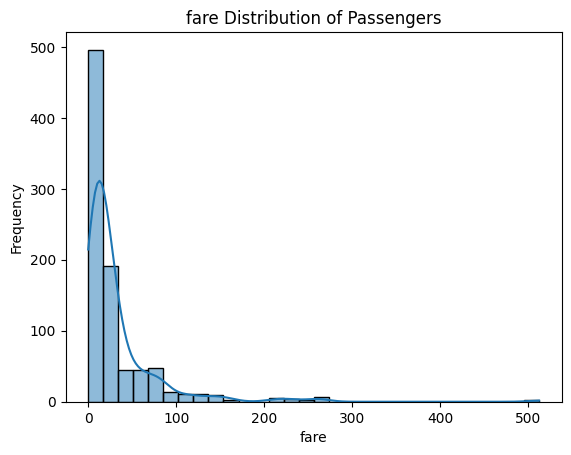

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt

# visualize Fare Distribution of Passengers:
sns.histplot(data['Fare'], bins=30, kde=True)

plt.title('fare Distribution of Passengers')
plt.xlabel('fare')
plt.ylabel('Frequency')
plt.show()

In [123]:
data["Fare_bin"] = pd.cut(data["Fare"], 6, labels=["Extremly Cheap", "Very Cheap", "Cheap", "Medium", "Expensive", "Very Expensive"])
data["Fare_bin"].value_counts(normalize=True)#פונקציה שלוקחת את העמודה ומחלקת אותה לפי המס' ומה שמקבלים זה 6 תאים לפי התגיות החלוקה לפי מקטעים באורך שווה

,proportion
Fare_bin,
Extremly Cheap,0.925926
Very Cheap,0.051627
Cheap,0.012346
Medium,0.006734
Very Expensive,0.003367
Expensive,0.000000


In [119]:
data["Fare_bin"].value_counts(normalize=True)

,proportion
Fare_bin,
Extremly Cheap,0.925926
Very Cheap,0.051627
Cheap,0.012346
Medium,0.006734
Very Expensive,0.003367
Expensive,0.000000


In [126]:
# see the diffrence between pd.qcut and pd.cut:
#לפי כותרת או לפי ערך
data["Fare_bin_qcut"] = pd.qcut(data["Fare"], q=6, labels=["Extremly Cheap", "Very Cheap", "Cheap", "Medium", "Expensive", "Very Expensive"])
data["Fare_bin_qcut"].value_counts(normalize=True)#אותו דבר אבל במקום לחלק מקטעים אז לכמות ערך סופי יחסית שווה

,proportion
Fare_bin_qcut,
Extremly Cheap,0.175084
Very Cheap,0.170595
Medium,0.167228
Very Expensive,0.167228
Expensive,0.163861
Cheap,0.156004


### other methods to explore correlation
cramer's V:
- Let’s measure the relationship between: embarkation port and survival

In [127]:
# Create contingency table
table = pd.crosstab(data["Embarked"], data["Survived"])
table

Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,217


In [128]:
# Compute Cramér’s V
# chi2_contingency computes the chi-square statistic to test whether two categorical variables are independent (i.e., not related).
import numpy as np
from scipy.stats import chi2_contingency

chi2 = chi2_contingency(table)[0]
n = table.sum().sum()

r, k = table.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))
cramers_v

np.float64(0.17261682709984438)

Embarkation port is less strongly related to survival.
- in general, values above ~0.5 are considered high.
- in general, values below ~0.3 are considered weak.

### for numerical columns we can use correlation matrix

In [129]:
numerical_cols = (
    data
    .select_dtypes(include=['int64', 'float64'])
    .columns
    .drop(['PassengerId'])
)

data[numerical_cols].corr()

,Survived,Pclass,Age,SibSp,Parch,Fare,age_class,Age_no_NA
Survived,1.000000,-0.338481,-0.050504,-0.035322,0.081629,0.257307,0.331417,-0.050504
Pclass,-0.338481,1.000000,-0.403858,0.083081,0.018443,-0.549500,-0.991023,-0.403858
Age,-0.050504,-0.403858,1.000000,-0.243452,-0.175799,0.120886,0.407516,1.000000
SibSp,-0.035322,0.083081,-0.243452,1.000000,0.414838,0.159651,-0.076853,-0.243452
Parch,0.081629,0.018443,-0.175799,0.414838,1.000000,0.216225,-0.018650,-0.175799
Fare,0.257307,-0.549500,0.120886,0.159651,0.216225,1.000000,0.574801,0.120886
age_class,0.331417,-0.991023,0.407516,-0.076853,-0.018650,0.574801,1.000000,0.407516
Age_no_NA,-0.050504,-0.403858,1.000000,-0.243452,-0.175799,0.120886,0.407516,1.000000


<Axes: >

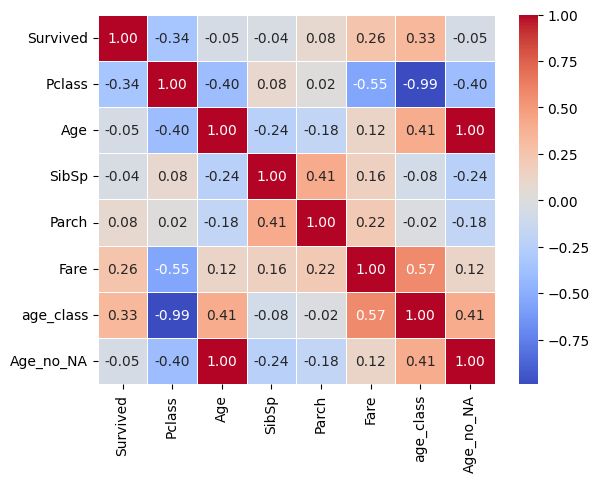

In [130]:
import seaborn as sns

sns.heatmap(data[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

remember
- correlation matrix is symmetric (The correlation between A and B is the same as between B and A)
- eigenvalues must be non-negative (measure how much total variance is captured)

In [135]:
"22/3/1995" < "23/3/1995"

True